# Notebook A: Image Classification
In this notebook, we'll apply image classification to the [STL-10 dataset](https://cs.stanford.edu/~acoates/stl10/). We'll cover data loading, preprocessing, training Multilayer Perceptron (MLP) model, and evaluating its performance. Through this exercise, you'll gain hands-on experience with fundamental machine learning workflows and image data handling.

### Setup imports

In [52]:
import random
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

### Load data
The full STL-10 dataset is very large (~2.3GB). For this notebook we will just work with the trainX.bin data. Still, the binary file for train_X.bin is too large for GitHub (136MB when the limit is 100MB). Instead download it from google drive, and put the file in the 'data' folder. https://drive.google.com/file/d/1X09rhyyAwrVgAOeOIZk0-HBqi_s5BL88/view?usp=sharing

These predefined functions will help will reading images and labels from the binary files. There is no need to modify them.

In [53]:
# Reads images from a binary file and returns them as a numpy array.
def read_images(file_path):
    image_size = 96 * 96 * 3  # Each image has 96x96 pixels with 3 channels
    with open(file_path, 'rb') as file:
        images = np.fromfile(file, dtype=np.uint8)
        images = images.reshape(-1, 3, 96, 96).transpose(0, 3, 2, 1)  # Reshape to proper format
    return images

# Reads labels from a binary file and returns them as a numpy array
def read_labels(file_path):
    with open(file_path, 'rb') as file:
        labels = np.fromfile(file, dtype=np.uint8)
    return labels

### Load images and labels using the above functions

In [54]:
import os

# List everything in the current directory and 'data' folder
print("Current directory files:", os.listdir())
if os.path.exists('data'):
    print("Contents of data/:", os.listdir('data'))
else:
    print("No 'data' folder found")


Current directory files: ['A_image_classification.ipynb', 'output.png', '.git', 'peroxidase_sequences.txt', 'B_peptide_sequence_generation.ipynb', 'train_X.bin', 'README.md', 'train_y.bin']
No 'data' folder found


In [55]:
# Define file path names
image_file = 'train_X.bin'
label_file = 'train_y.bin'

# Load the images and labels
images = read_images(image_file)
labels = read_labels(label_file)


In [56]:
assert images.shape == (5000, 96, 96, 3)
assert labels.shape == (5000,)

### Print first three images

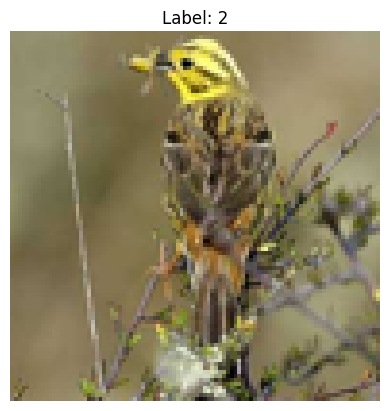

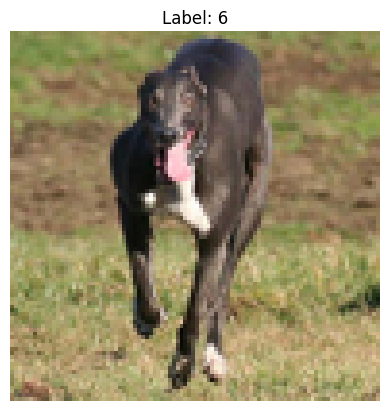

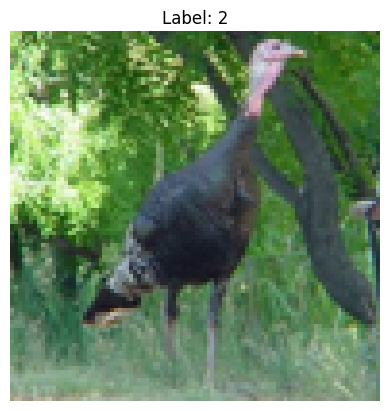

In [57]:
# define a function to display an image
def show_image(img, lbl=None):
    plt.imshow(img.astype(np.uint8))
    plt.title(f"Label: {lbl}" if lbl is not None else "")
    plt.axis('off')
    plt.show()


# write a loop to display the first 3 images
for i in range(3):
    show_image(images[i], labels[i])


### Preprocess images

In [58]:
# inspect the image data structure
print("Shape:", X.shape)            
print("Data type:", X.dtype)        
print("Min pixel value:", X.min())  
print("Max pixel value:", X.max())


Shape: (5000, 96, 96, 3)
Data type: float32
Min pixel value: 0.0
Max pixel value: 2.3650445e-10


In [59]:
# normalize all values to be between 0 and 1
X = X / 255.0 

X = X.astype(np.float32)

#after normalization values
print("Min pixel value after normalization:", X.min())
print("Max pixel value after normalization:", X.max())

Min pixel value after normalization: 0.0
Max pixel value after normalization: 9.274685e-13


### Perform train test split

In [60]:
# split the data into training and test sets (80% train, 20% test) using random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


# To confirm the shapes
print(X_train.shape, X_test.shape)


(4000, 96, 96, 3) (1000, 96, 96, 3)


### Define and Train the Model
First define the ML model using the `MLPClassifier` from scikit-learn. Use the hyperparameters: `hidden_layer_sizes=(512,), activation='relu', solver='adam', max_iter=10, verbose=True, random_state=42`

Note: you will need to flatten the images before training the model

In [67]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

clf = MLPClassifier(random_state=42)
clf.fit(X_train_flat, y_train)


MLPClassifier(random_state=42)

### Evaluate the Model
After training, evaluate the model's performance on the test using `accuracy_score`

In [74]:
y_pred = clf.predict(X_test_flat)
# Determine the accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.1


In [77]:
assert test_accuracy > 0.30 and test_accuracy < 0.32

# Assertion failed: model underfits, accuracy too low (~10%)

AssertionError: 

### Visualize Misclassified Examples
Display the first 3 mislabeled images in `test_predictions`. Print the image, the predicted label, and the true label.

Note: the image labels are: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck

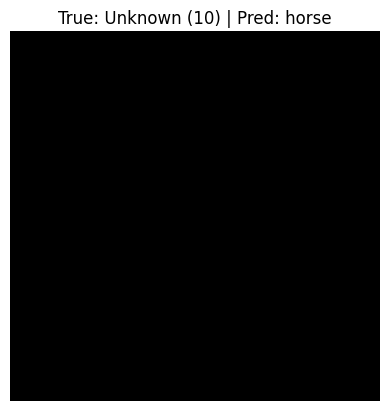

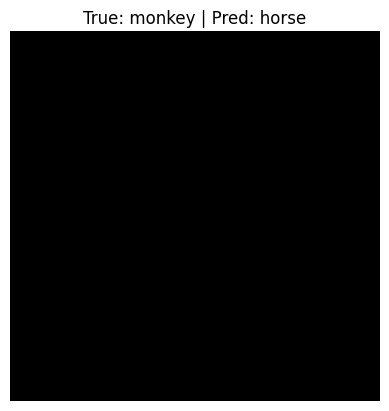

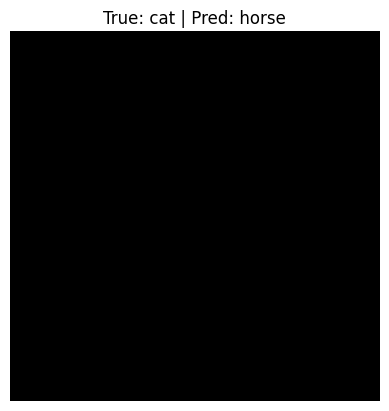

In [84]:
label_names = ['airplane', 'bird', 'car', 'cat', 'deer',
               'dog', 'horse', 'monkey', 'ship', 'truck']
def safe_label(index):
    return label_names[index] if 0 <= index < len(label_names) else f"Unknown ({index})"

for i in misclassified_indices[:3]:
    plt.imshow(X_test[i].astype(np.uint8))
    plt.title(f"True: {safe_label(y_test[i])} | Pred: {safe_label(y_pred[i])}")
    plt.axis('off')
    plt.show()
